# 02 — Análisis Exploratorio de Datos (EDA)

Fase 2: EDA sobre la base de datos seleccionada.

## Calidad de los datos: faltantes, duplicados y consistencia

Antes de describir las variables o buscar relaciones entre ellas, revisamos qué tan confiable es la base. Como vimos en las guías de las semanas 1 a 3, la limpieza es una de las primeras etapas del análisis: un dato crudo puede traer valores faltantes, registros repetidos, categorías mal escritas o valores que no tienen sentido, y si no los detectamos a tiempo terminan afectando todo lo que viene después.

En esta sección **solo diagnosticamos** los problemas: los contamos, miramos dónde se concentran y proponemos cómo tratarlos. No imputamos, no eliminamos ni transformamos ningún registro, porque esas decisiones se aplican en el notebook `03_preprocesamiento_reduccion.ipynb`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# Si las celdas de exploración anteriores ya crearon `df`, se reutiliza.
# La carga de respaldo permite ejecutar esta sección de forma independiente.
if "df" not in globals():
    rutas_candidatas = [
        Path("../data/raw/hcvdat0.csv"),
        Path("data/raw/hcvdat0.csv"),
    ]
    ruta_hcv = next((ruta for ruta in rutas_candidatas if ruta.exists()), None)
    if ruta_hcv is None:
        raise FileNotFoundError("No se encontró data/raw/hcvdat0.csv.")
    df = pd.read_csv(ruta_hcv)

# El diagnóstico se hace sobre una copia para preservar los datos cargados.
df_calidad = df.copy()
columna_id = df_calidad.columns[0]
print(f"Registros analizados: {len(df_calidad):,}")
print(f"Columnas analizadas: {df_calidad.shape[1]}")

# Carpeta de imágenes del proyecto, resuelta de forma relativa igual que los datos.
carpeta_imagenes = next(
    (ruta for ruta in [Path("../images"), Path("images")] if ruta.is_dir()),
    Path("../images"),
)

Registros analizados: 615
Columnas analizadas: 14


### Valores faltantes

Primero contamos cuántos valores faltan en cada columna y qué porcentaje representan frente a los 615 registros. Así podemos comparar la magnitud del problema entre variables y no solo mirar el número absoluto.

In [2]:
resumen_faltantes = pd.DataFrame({
    "cantidad_faltante": df_calidad.isna().sum(),
    "porcentaje_faltante": df_calidad.isna().mean().mul(100),
})
resumen_faltantes["porcentaje_faltante"] = (
    resumen_faltantes["porcentaje_faltante"].round(3)
)
resumen_faltantes = resumen_faltantes.sort_values(
    "cantidad_faltante", ascending=False
)
display(resumen_faltantes)

faltantes_totales = int(df_calidad.isna().sum().sum())
filas_con_faltantes = int(df_calidad.isna().any(axis=1).sum())
print(f"Celdas faltantes: {faltantes_totales}")
print(
    f"Filas con al menos un faltante: {filas_con_faltantes} "
    f"({filas_con_faltantes / len(df_calidad) * 100:.3f}%)"
)

,cantidad_faltante,porcentaje_faltante
ALP,18,2.927
CHOL,10,1.626
ALT,1,0.163
PROT,1,0.163
ALB,1,0.163
Category,0,0.000
Age,0,0.000
Sex,0,0.000
Unnamed: 0,0,0.000
AST,0,0.000


Celdas faltantes: 31
Filas con al menos un faltante: 26 (4.228%)


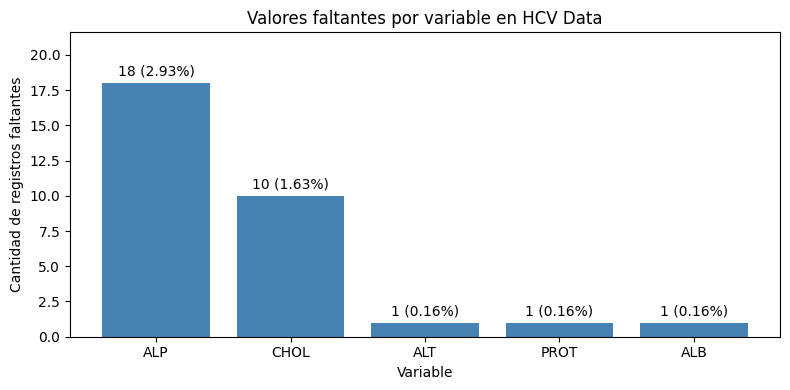

In [3]:
import matplotlib.pyplot as plt

faltantes_grafico = resumen_faltantes.query("cantidad_faltante > 0")

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.bar(
    faltantes_grafico.index,
    faltantes_grafico["cantidad_faltante"],
    color="steelblue",
)
ax.bar_label(
    barras,
    labels=[
        f"{cantidad} ({porcentaje:.2f}%)"
        for cantidad, porcentaje in zip(
            faltantes_grafico["cantidad_faltante"],
            faltantes_grafico["porcentaje_faltante"],
        )
    ],
    padding=3,
)
ax.set_title("Valores faltantes por variable en HCV Data")
ax.set_xlabel("Variable")
ax.set_ylabel("Cantidad de registros faltantes")
ax.set_ylim(0, faltantes_grafico["cantidad_faltante"].max() * 1.2)
plt.tight_layout()
fig.savefig(carpeta_imagenes / "faltantes_por_variable.png", dpi=150)
plt.show()

Con la tabla y la gráfica vemos que el problema de faltantes está concentrado en muy pocas columnas. Solo 5 de las 14 columnas tienen datos ausentes, y todas son pruebas de laboratorio: `ALP` es la más afectada, seguida de `CHOL`, mientras que `ALB`, `ALT` y `PROT` tienen un único faltante cada una. Las variables `Category`, `Age` y `Sex` están completas, lo cual es importante porque son las que usamos para agrupar y comparar pacientes.

Ahora bien, que el porcentaje global sea bajo no quiere decir que el problema sea menor. Hay que mirar **en qué grupos** caen esos faltantes.

In [4]:
columnas_con_faltantes = resumen_faltantes.query(
    "cantidad_faltante > 0"
).index.tolist()
faltantes_por_categoria = (
    df_calidad.groupby("Category", observed=False)[columnas_con_faltantes]
    .agg(lambda serie: serie.isna().sum())
)
display(faltantes_por_categoria)

# Porcentajes dentro de cada categoría: permiten detectar concentración del problema.
porcentaje_faltantes_por_categoria = (
    df_calidad.groupby("Category", observed=False)[columnas_con_faltantes]
    .agg(lambda serie: serie.isna().mean() * 100)
    .round(2)
)
display(porcentaje_faltantes_por_categoria)

,ALP,CHOL,ALT,PROT,ALB
Category,,,,,
0=Blood Donor,0,7,0,0,0
0s=suspect Blood Donor,0,0,0,0,0
1=Hepatitis,3,0,1,0,0
2=Fibrosis,9,1,0,0,0
3=Cirrhosis,6,2,0,1,1


,ALP,CHOL,ALT,PROT,ALB
Category,,,,,
0=Blood Donor,0.00,1.31,0.00,0.00,0.00
0s=suspect Blood Donor,0.00,0.00,0.00,0.00,0.00
1=Hepatitis,12.50,0.00,4.17,0.00,0.00
2=Fibrosis,42.86,4.76,0.00,0.00,0.00
3=Cirrhosis,20.00,6.67,0.00,3.33,3.33


In [5]:
# Registros con más de un faltante: conviene revisarlos uno por uno.
faltantes_por_fila = df_calidad.isna().sum(axis=1)
print("Filas según cantidad de faltantes:")
display(
    faltantes_por_fila[faltantes_por_fila > 0]
    .value_counts()
    .sort_index()
    .rename_axis("faltantes_en_la_fila")
    .to_frame("cantidad_de_filas")
)

filas_varios_faltantes = df_calidad.loc[faltantes_por_fila > 1]
display(filas_varios_faltantes)
for indice, fila in filas_varios_faltantes.iterrows():
    columnas_ausentes = fila[fila.isna()].index.tolist()
    print(f"{columna_id} = {fila[columna_id]} ({fila['Category']}): falta {columnas_ausentes}")

Filas según cantidad de faltantes:


,cantidad_de_filas
faltantes_en_la_fila,
1,23
2,1
3,2


,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
584,585,2=Fibrosis,75,f,36.0,NaN,114.0,125.0,14.0,6.65,NaN,57.0,177.0,72.0
590,591,3=Cirrhosis,46,m,20.0,NaN,62.0,113.0,254.0,1.48,NaN,114.0,138.0,NaN
603,604,3=Cirrhosis,65,m,NaN,NaN,40.0,54.0,13.0,7.50,NaN,70.0,107.0,79.0


Unnamed: 0 = 585 (2=Fibrosis): falta ['ALP', 'CHOL']
Unnamed: 0 = 591 (3=Cirrhosis): falta ['ALP', 'CHOL', 'PROT']
Unnamed: 0 = 604 (3=Cirrhosis): falta ['ALB', 'ALP', 'CHOL']


#### Interpretación e impacto de los faltantes

Al separar por diagnóstico aparece el hallazgo más importante de esta sección: **los faltantes de `ALP` no están repartidos al azar**. Ningún donante (sano o sospechoso) tiene `ALP` vacío; los 18 casos están en los grupos clínicos: 3 en Hepatitis (12.5% del grupo), 9 en Fibrosis (42.86%) y 6 en Cirrosis (20%). O sea, casi la mitad de los pacientes con fibrosis no tiene esa prueba registrada.

Esto pesa mucho porque los grupos clínicos son pequeños (24, 21 y 30 registros frente a 533 donantes). Si simplemente borráramos las filas incompletas, perderíamos una parte grande justo de los pacientes que más nos interesan y el desbalance entre clases sería todavía peor.

| Variable | Faltantes | % global | Dónde se concentran | Impacto | Estrategia propuesta (se aplica en el notebook 03) |
|---|---:|---:|---|---|---|
| `ALP` | 18 | 2.93% | Hepatitis (3), Fibrosis (9), Cirrosis (6) | Alto: afecta solo a grupos clínicos pequeños | No eliminar filas. Imputar con la **mediana** del grupo diagnóstico y evaluar crear un **indicador** de faltante, ya que la ausencia misma parece estar relacionada con el diagnóstico |
| `CHOL` | 10 | 1.63% | Donantes (7), Fibrosis (1), Cirrosis (2) | Medio: bajo en donantes, pero afecta a grupos clínicos | Imputar con la **mediana** del grupo diagnóstico |
| `ALB` | 1 | 0.16% | Cirrosis (1) | Bajo | Imputar con la mediana del grupo; el registro también tiene vacíos `ALP` y `CHOL`, por eso se revisa junto con ellos |
| `ALT` | 1 | 0.16% | Hepatitis (1) | Bajo | Imputar con la mediana del grupo |
| `PROT` | 1 | 0.16% | Cirrosis (1) | Bajo | Imputar con la mediana del grupo; el registro también tiene vacíos `ALP` y `CHOL` |

En total hay **31 celdas vacías repartidas en 26 filas (4.23% de los registros)**: 23 filas tienen un solo faltante, 1 fila tiene dos y 2 filas tienen tres. Esas dos filas con tres faltantes son pacientes con cirrosis, y ojo que `ALB` y `PROT` **no** están en el mismo registro: a uno le falta `ALB`, `ALP` y `CHOL`, y al otro `ALP`, `CHOL` y `PROT`.

Proponemos la **mediana** y no la media porque, como vimos en la semana 4, la media es sensible a valores extremos, y en estas pruebas de laboratorio hay máximos muy altos. Además, calcularla por grupo diagnóstico evita rellenar a un paciente con cirrosis usando valores típicos de donantes sanos.

### Registros duplicados

Buscamos duplicados de dos formas: comparando todas las columnas y comparando todas **menos** la primera, que funciona como identificador. La segunda revisión es la importante, porque dos filas con los mismos valores clínicos pero con número de registro distinto no aparecerían como duplicadas en la primera.

In [6]:
duplicados_exactos = df_calidad.duplicated(keep=False)
columnas_sin_id = df_calidad.columns.drop(columna_id)
duplicados_sin_id = df_calidad.duplicated(
    subset=columnas_sin_id, keep=False
)
print(f"Filas involucradas en duplicados exactos: {duplicados_exactos.sum()}")
print(
    "Filas involucradas en duplicados al ignorar el identificador: "
    f"{duplicados_sin_id.sum()}"
)
if duplicados_sin_id.any():
    display(df_calidad.loc[duplicados_sin_id].sort_values(list(columnas_sin_id)))

Filas involucradas en duplicados exactos: 0
Filas involucradas en duplicados al ignorar el identificador: 0


**Interpretación:** no encontramos registros duplicados en ninguna de las dos revisiones, así que no hay que eliminar filas por este motivo. Esta verificación hay que repetirla en el notebook 03 después de cualquier transformación, por si algún paso de limpieza llega a generar filas repetidas.

### Valores inconsistentes y posibles errores de formato

Revisamos que las variables categóricas solo tengan los valores esperados (sin espacios de más ni variantes en mayúsculas/minúsculas), que el identificador no se repita ni tenga vacíos y que las columnas que deberían ser numéricas no tengan texto escondido.

In [7]:
categorias_esperadas = {
    "0=Blood Donor",
    "0s=suspect Blood Donor",
    "1=Hepatitis",
    "2=Fibrosis",
    "3=Cirrhosis",
}
sexos_esperados = {"m", "f"}
categorias_observadas = set(df_calidad["Category"].dropna().unique())
sexos_observados = set(df_calidad["Sex"].dropna().unique())

resumen_consistencia = pd.Series({
    "categorias_no_reconocidas": len(categorias_observadas - categorias_esperadas),
    "sexos_no_reconocidos": len(sexos_observados - sexos_esperados),
    "identificadores_duplicados": int(df_calidad[columna_id].duplicated().sum()),
    "identificadores_faltantes": int(df_calidad[columna_id].isna().sum()),
    "identificador_secuencial_1_a_n": bool(
        df_calidad[columna_id].reset_index(drop=True).eq(
            pd.Series(range(1, len(df_calidad) + 1))
        ).all()
    ),
})
display(resumen_consistencia.to_frame("resultado"))

for columna in ["Category", "Sex"]:
    print(f"Valores y frecuencias de {columna}:")
    display(df_calidad[columna].value_counts(dropna=False).to_frame("frecuencia"))

,resultado
categorias_no_reconocidas,0
sexos_no_reconocidos,0
identificadores_duplicados,0
identificadores_faltantes,0
identificador_secuencial_1_a_n,True


Valores y frecuencias de Category:


,frecuencia
Category,
0=Blood Donor,533
3=Cirrhosis,30
1=Hepatitis,24
2=Fibrosis,21
0s=suspect Blood Donor,7


Valores y frecuencias de Sex:


,frecuencia
Sex,
m,377
f,238


In [8]:
columnas_categoricas = ["Category", "Sex"]
columnas_numericas_esperadas = [
    columna for columna in df_calidad.columns
    if columna not in columnas_categoricas
]
filas_con_espacios = pd.Series(False, index=df_calidad.index)
for columna in columnas_categoricas:
    serie_texto = df_calidad[columna].astype("string")
    filas_con_espacios |= serie_texto.ne(serie_texto.str.strip()).fillna(False)

conversion_numerica = df_calidad[columnas_numericas_esperadas].apply(
    pd.to_numeric, errors="coerce"
)
errores_conversion = (
    conversion_numerica.isna() & df_calidad[columnas_numericas_esperadas].notna()
).sum()
valores_infinitos = np.isinf(conversion_numerica).sum()
display(pd.DataFrame({
    "errores_conversion_numerica": errores_conversion,
    "valores_infinitos": valores_infinitos,
}))
print(f"Filas con espacios al inicio o al final: {filas_con_espacios.sum()}")

,errores_conversion_numerica,valores_infinitos
Unnamed: 0,0,0
Age,0,0
ALB,0,0
ALP,0,0
ALT,0,0
AST,0,0
BIL,0,0
CHE,0,0
CHOL,0,0
CREA,0,0


Filas con espacios al inicio o al final: 0


**Interpretación:** `Category` solo tiene las cinco etiquetas documentadas y `Sex` solo `m` y `f`, sin espacios ni variantes. Las columnas numéricas no tienen texto inesperado ni valores infinitos, y el identificador va de 1 a 615 sin repetirse. En ese sentido, la base está bien construida.

Aun así encontramos tres detalles de formato que hay que tener en cuenta para el preprocesamiento:

1. **Columna sin nombre.** La primera columna llega del CSV sin encabezado y pandas la nombra `Unnamed: 0`. Por sus valores es solo un número de registro, no una medición clínica, así que en el notebook 03 hay que renombrarla o quitarla antes de escalar o aplicar PCA; si se deja, el modelo la tomaría como si fuera información del paciente.
2. **Etiquetas de `Category` que mezclan código y texto.** Valores como `0=Blood Donor` o `3=Cirrhosis` traen el número y el nombre en el mismo texto. Sirven para leer, pero para codificar habrá que separarlos o mapearlos de forma explícita.
3. **La categoría `0s=suspect Blood Donor`.** Son solo 7 registros de donantes "sospechosos", que no encajan del todo ni como sanos ni como enfermos. No es un error de digitación, pero sí una categoría ambigua; queda pendiente decidir si se conserva aparte o se agrupa con otra clase, y esa decisión debe justificarse con los análisis siguientes.

### Rangos aparentemente inválidos

Acá no usamos rangos clínicos de referencia, porque no somos médicos y un valor muy alto puede ser perfectamente normal en un paciente enfermo. Aplicamos reglas mínimas de validez: la edad debe estar entre 0 y 120 años y las mediciones de laboratorio deben ser mayores que cero (no existe una concentración negativa).

In [9]:
columnas_clinicas = [
    "ALB", "ALP", "ALT", "AST", "BIL",
    "CHE", "CHOL", "CREA", "GGT", "PROT",
]
rangos_observados = df_calidad[["Age"] + columnas_clinicas].agg(
    ["min", "max"]
).T
rangos_observados["valores_no_positivos"] = (
    df_calidad[["Age"] + columnas_clinicas] <= 0
).sum()
display(rangos_observados)

edad_invalida = ~df_calidad["Age"].between(0, 120, inclusive="both")
clinicos_invalidos = (df_calidad[columnas_clinicas] <= 0).sum()
print(f"Edades fuera de 0–120 años: {edad_invalida.sum()}")
print(f"Mediciones clínicas no positivas: {clinicos_invalidos.sum()}")

,min,max,valores_no_positivos
Age,19.00,77.00,0
ALB,14.90,82.20,0
ALP,11.30,416.60,0
ALT,0.90,325.30,0
AST,10.60,324.00,0
BIL,0.80,254.00,0
CHE,1.42,16.41,0
CHOL,1.43,9.67,0
CREA,8.00,1079.10,0
GGT,4.50,650.90,0


Edades fuera de 0–120 años: 0
Mediciones clínicas no positivas: 0


**Interpretación:** no hay edades imposibles ni valores negativos o en cero en las pruebas de laboratorio. Las edades van de 19 a 77 años, lo cual es razonable. Sí llaman la atención algunos máximos muy altos, por ejemplo `CREA` (1079.1), `GGT` (650.9), `ALT`, `AST` y `BIL`, pero pueden corresponder a pacientes con enfermedad hepática, así que por ahora **no los consideramos errores**. Su revisión como posibles valores atípicos (boxplots, IQR) corresponde a la sección de distribuciones y outliers.

### Conclusión del diagnóstico de calidad

En general, HCV Data es una base limpia en estructura: no tiene duplicados, las categorías están bien escritas, los tipos de datos son correctos y no hay rangos imposibles. El problema principal son los **valores faltantes**, que aunque son pocos (4.23% de las filas) se concentran en los grupos clínicos, sobre todo `ALP` en Fibrosis.

Resumen de lo que queda para el preprocesamiento (notebook 03):

| Problema detectado | Propuesta |
|---|---|
| 18 faltantes de `ALP` concentrados en grupos clínicos | No eliminar filas; imputar con la mediana por diagnóstico y evaluar un indicador de faltante |
| Faltantes aislados en `CHOL`, `ALB`, `ALT` y `PROT` | Imputar con la mediana por diagnóstico |
| Columna identificadora sin nombre (`Unnamed: 0`) | Renombrarla o excluirla antes de escalar y aplicar PCA |
| Etiquetas de `Category` con código y texto juntos | Separarlos o mapearlos antes de codificar |
| Categoría ambigua `0s=suspect Blood Donor` (7 registros) | Decidir con justificación si se conserva o se agrupa |

Ninguna de estas correcciones se aplica todavía: dejamos los datos originales intactos para que el diagnóstico quede separado de la limpieza definitiva.